# Dynamic Programming on GridWorld and FrozenLake



## 1. Setup

In [14]:

# If Gymnasium is not installed, uncomment the next line and run once:
# %pip install gymnasium

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

try:
    import gymnasium as gym
except ImportError:
    gym = None
    print("Gymnasium is not installed in this environment. Install it before running FrozenLake cells.")

np.set_printoptions(precision=3, suppress=True)

ACTIONS = {
    0: (-1, 0),   # up
    1: (1, 0),    # down
    2: (0, -1),   # left
    3: (0, 1),    # right
}
ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}
ACTION_ARROWS = {0: "↑", 1: "↓", 2: "←", 3: "→"}

## 2. Custom GridWorld Environment

This environment follows the **Gymnasium API style**:

- `reset()` returns `(state, info)`
- `step(action)` returns `(next_state, reward, terminated, truncated, info)`



In [15]:

class GridWorldEnv:
    """
    Simple configurable GridWorld with Gymnasium-style reset() and step().
    """

    def __init__(
        self,
        nrows=5,
        ncols=5,
        start=(0, 0),
        goal=(4, 4),
        obstacles=None,
        terminal_rewards=None,
        default_reward=-0.04,
        slip_prob=0.0,
        seed=42,
    ):
        self.nrows = nrows
        self.ncols = ncols
        self.start = start
        self.goal = goal
        self.obstacles = set(obstacles or [])
        self.default_reward = default_reward
        self.slip_prob = slip_prob
        self.rng = np.random.default_rng(seed)

        self.terminal_rewards = dict(terminal_rewards or {})
        self.terminal_rewards[self.goal] = self.terminal_rewards.get(self.goal, 1.0)

        self.action_space = type("ActionSpace", (), {"n": 4})()
        self.observation_space = type("ObservationSpace", (), {"n": nrows * ncols})()

        self.P = self._build_transition_model()
        self.state = self.to_state(self.start)

    def to_state(self, pos):
        return pos[0] * self.ncols + pos[1]

    def to_pos(self, state):
        return divmod(state, self.ncols)

    def is_terminal_pos(self, pos):
        return pos in self.terminal_rewards

    def valid_pos(self, pos):
        r, c = pos
        return 0 <= r < self.nrows and 0 <= c < self.ncols and pos not in self.obstacles

    def _move(self, pos, action):
        if self.is_terminal_pos(pos):
            return pos
        dr, dc = ACTIONS[action]
        nxt = (pos[0] + dr, pos[1] + dc)
        return nxt if self.valid_pos(nxt) else pos

    def _action_outcomes(self, action):
        if self.slip_prob <= 0.0:
            return [(1.0, action)]

        side_prob = self.slip_prob / 2.0
        if action in (0, 1):
            return [(1.0 - self.slip_prob, action), (side_prob, 2), (side_prob, 3)]
        else:
            return [(1.0 - self.slip_prob, action), (side_prob, 0), (side_prob, 1)]

    def _build_transition_model(self):
        P = {s: {a: [] for a in range(4)} for s in range(self.nrows * self.ncols)}

        for s in range(self.nrows * self.ncols):
            pos = self.to_pos(s)
            for a in range(4):
                if pos in self.obstacles:
                    P[s][a] = [(1.0, s, 0.0, True)]
                    continue

                if self.is_terminal_pos(pos):
                    P[s][a] = [(1.0, s, 0.0, True)]
                    continue

                merged = {}
                for prob, actual_action in self._action_outcomes(a):
                    nxt_pos = self._move(pos, actual_action)
                    ns = self.to_state(nxt_pos)
                    terminated = self.is_terminal_pos(nxt_pos)
                    reward = self.terminal_rewards.get(nxt_pos, self.default_reward)
                    key = (ns, reward, terminated)
                    merged[key] = merged.get(key, 0.0) + prob

                P[s][a] = [(p, ns, r, t) for (ns, r, t), p in merged.items()]

        return P

    def get_transition_model(self):
        return self.P

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.to_state(self.start)
        return self.state, {}

    def step(self, action):
        transitions = self.P[self.state][action]
        probs = [p for p, _, _, _ in transitions]
        idx = self.rng.choice(len(transitions), p=probs)
        _, ns, r, terminated = transitions[idx]
        self.state = ns
        truncated = False
        return ns, r, terminated, truncated, {}

In [16]:

def extract_transition_model(env):
    if hasattr(env, "get_transition_model"):
        P = env.get_transition_model()
    elif hasattr(env, "P"):
        P = env.P
    else:
        P = env.unwrapped.P

    nS = env.observation_space.n
    nA = env.action_space.n
    return P, nS, nA


def q_values_from_V(P, V, s, gamma):
    nA = len(P[s])
    q = np.zeros(nA)
    for a in range(nA):
        q[a] = sum(p * (r + gamma * V[ns] * (not terminated)) for p, ns, r, terminated in P[s][a])
    return q


def greedy_policy_from_V(P, V, gamma):
    nS = len(P)
    policy = np.zeros(nS, dtype=int)
    for s in range(nS):
        policy[s] = np.argmax(q_values_from_V(P, V, s, gamma))
    return policy

## 3. Dynamic Programming Algorithms

In [17]:

def policy_evaluation_sync(P, policy, gamma=0.99, theta=1e-6, max_sweeps=10_000):
    nS = len(P)
    V = np.zeros(nS)
    history = [V.copy()]
    deltas = []

    for _ in range(max_sweeps):
        V_new = V.copy()
        delta = 0.0
        for s in range(nS):
            a = policy[s]
            v = sum(p * (r + gamma * V[ns] * (not terminated)) for p, ns, r, terminated in P[s][a])
            V_new[s] = v
            delta = max(delta, abs(v - V[s]))
        V = V_new
        history.append(V.copy())
        deltas.append(delta)
        if delta < theta:
            break

    return V, history, deltas


def policy_evaluation_inplace(P, policy, gamma=0.99, theta=1e-6, max_sweeps=10_000):
    nS = len(P)
    V = np.zeros(nS)
    history = [V.copy()]
    deltas = []

    for _ in range(max_sweeps):
        delta = 0.0
        for s in range(nS):
            a = policy[s]
            old_v = V[s]
            V[s] = sum(p * (r + gamma * V[ns] * (not terminated)) for p, ns, r, terminated in P[s][a])
            delta = max(delta, abs(V[s] - old_v))
        history.append(V.copy())
        deltas.append(delta)
        if delta < theta:
            break

    return V, history, deltas


def policy_iteration(P, gamma=0.99, theta=1e-6, mode="sync"):
    nS = len(P)
    policy = np.zeros(nS, dtype=int)
    evaluation_fn = policy_evaluation_sync if mode == "sync" else policy_evaluation_inplace

    outer_history = []
    total_eval_sweeps = 0
    t0 = time.perf_counter()

    while True:
        V, eval_history, eval_deltas = evaluation_fn(P, policy, gamma=gamma, theta=theta)
        total_eval_sweeps += len(eval_deltas)

        new_policy = greedy_policy_from_V(P, V, gamma)
        stable = np.array_equal(new_policy, policy)

        outer_history.append({
            "V": V.copy(),
            "policy": new_policy.copy(),
            "eval_history": eval_history,
            "eval_deltas": eval_deltas,
            "eval_sweeps": len(eval_deltas),
        })

        policy = new_policy
        if stable:
            break

    elapsed = time.perf_counter() - t0
    return {
        "algorithm": f"Policy Iteration ({mode})",
        "V": V,
        "policy": policy,
        "outer_iterations": len(outer_history),
        "total_sweeps": total_eval_sweeps,
        "time_seconds": elapsed,
        "history": outer_history,
    }


def value_iteration(P, gamma=0.99, theta=1e-6, mode="sync", max_sweeps=10_000):
    nS = len(P)
    nA = len(P[0])
    V = np.zeros(nS)
    history = [V.copy()]
    deltas = []
    t0 = time.perf_counter()

    for _ in range(max_sweeps):
        delta = 0.0
        if mode == "sync":
            V_new = V.copy()
            for s in range(nS):
                q = np.zeros(nA)
                for a in range(nA):
                    q[a] = sum(p * (r + gamma * V[ns] * (not terminated)) for p, ns, r, terminated in P[s][a])
                V_new[s] = np.max(q)
                delta = max(delta, abs(V_new[s] - V[s]))
            V = V_new
        else:
            for s in range(nS):
                old_v = V[s]
                q = np.zeros(nA)
                for a in range(nA):
                    q[a] = sum(p * (r + gamma * V[ns] * (not terminated)) for p, ns, r, terminated in P[s][a])
                V[s] = np.max(q)
                delta = max(delta, abs(V[s] - old_v))
        history.append(V.copy())
        deltas.append(delta)
        if delta < theta:
            break

    elapsed = time.perf_counter() - t0
    policy = greedy_policy_from_V(P, V, gamma)

    return {
        "algorithm": f"Value Iteration ({mode})",
        "V": V,
        "policy": policy,
        "sweeps": len(deltas),
        "time_seconds": elapsed,
        "history": history,
        "deltas": deltas,
    }

## 4. Plotting Helpers

In [18]:

def value_grid(V, env):
    grid = V.reshape(env.nrows, env.ncols).astype(float).copy()
    for pos in env.obstacles:
        grid[pos] = np.nan
    return grid


def policy_to_quiver(policy, env):
    U = np.zeros((env.nrows, env.ncols))
    W = np.zeros((env.nrows, env.ncols))

    for s, a in enumerate(policy):
        r, c = env.to_pos(s)
        if (r, c) in env.obstacles or (r, c) in env.terminal_rewards:
            continue
        if a == 0:
            U[r, c], W[r, c] = 0, -1
        elif a == 1:
            U[r, c], W[r, c] = 0, 1
        elif a == 2:
            U[r, c], W[r, c] = -1, 0
        elif a == 3:
            U[r, c], W[r, c] = 1, 0

    return U, W


def draw_grid_background(ax, env):
    bg = np.zeros((env.nrows, env.ncols))
    ax.imshow(bg, cmap=ListedColormap(["white"]), vmin=0, vmax=1)
    ax.set_xticks(np.arange(-0.5, env.ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.nrows, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    for r in range(env.nrows):
        for c in range(env.ncols):
            pos = (r, c)
            if pos in env.obstacles:
                ax.text(c, r, "X", ha="center", va="center", fontsize=14, fontweight="bold")
            elif pos == env.start:
                ax.text(c, r, "S", ha="center", va="center", fontsize=12, fontweight="bold")
            elif pos == env.goal:
                ax.text(c, r, "G", ha="center", va="center", fontsize=12, fontweight="bold")
            elif pos in env.terminal_rewards and pos != env.goal:
                ax.text(c, r, "T", ha="center", va="center", fontsize=12, fontweight="bold")


def plot_value_snapshots(history, env, title, max_panels=6):
    n = len(history)
    idx = np.linspace(0, n - 1, min(max_panels, n), dtype=int)

    fig, axes = plt.subplots(1, len(idx), figsize=(4 * len(idx), 4), constrained_layout=True)
    if len(idx) == 1:
        axes = [axes]

    for ax, i in zip(axes, idx):
        grid = value_grid(history[i], env)
        im = ax.imshow(grid, cmap="viridis")
        ax.set_title(f"Iteration {i}")
        ax.set_xticks(range(env.ncols))
        ax.set_yticks(range(env.nrows))
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        for r in range(env.nrows):
            for c in range(env.ncols):
                pos = (r, c)
                if pos in env.obstacles:
                    ax.text(c, r, "X", ha="center", va="center", color="white", fontweight="bold")
                else:
                    if not np.isnan(grid[r, c]):
                        ax.text(c, r, f"{grid[r, c]:.2f}", ha="center", va="center", color="white", fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title, fontsize=14)
    plt.show()


def plot_policy_snapshots(policy_list, env, titles):
    n = len(policy_list)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, policy, name in zip(axes, policy_list, titles):
        draw_grid_background(ax, env)
        U, W = policy_to_quiver(policy, env)
        X, Y = np.meshgrid(np.arange(env.ncols), np.arange(env.nrows))
        ax.quiver(X, Y, U, W, angles="xy", scale_units="xy", scale=2.2)
        ax.set_title(name)

    plt.show()


def plot_convergence(results, title):
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    for name, deltas in results.items():
        ax.plot(deltas, label=name)
    ax.set_title(title)
    ax.set_xlabel("Sweep")
    ax.set_ylabel("max change in V")
    ax.set_yscale("log")
    ax.legend()
    plt.show()


def compare_runtime_bar(summary_rows, title):
    labels = [row["Algorithm"] for row in summary_rows]
    times = [row["Time (s)"] for row in summary_rows]
    sweeps = [row["Sweeps"] for row in summary_rows]
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    ax.bar(x, times)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    ax.bar(x, sweeps)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Number of sweeps")
    ax.set_title(title + " — sweeps")
    plt.show()

## 5. Build Two GridWorld Configurations

We will test two versions of the same 5×5 world:

1. **Deterministic GridWorld**  
2. **Stochastic GridWorld** with 80% intended direction and 10% to each perpendicular direction

Both worlds include a goal state with reward `+1`, one negative terminal state with reward `-1`, obstacles, and a small step cost `-0.04`.

In [19]:

det_env = GridWorldEnv(
    nrows=5,
    ncols=5,
    start=(0, 0),
    goal=(4, 4),
    obstacles={(1, 1), (2, 2), (3, 1)},
    terminal_rewards={(4, 0): -1.0, (4, 4): 1.0},
    default_reward=-0.04,
    slip_prob=0.0,
)

stoch_env = GridWorldEnv(
    nrows=5,
    ncols=5,
    start=(0, 0),
    goal=(4, 4),
    obstacles={(1, 1), (2, 2), (3, 1)},
    terminal_rewards={(4, 0): -1.0, (4, 4): 1.0},
    default_reward=-0.04,
    slip_prob=0.2,
)

P_det, nS_det, nA_det = extract_transition_model(det_env)
P_sto, nS_sto, nA_sto = extract_transition_model(stoch_env)

print("Deterministic transitions from start state, action Right:")
print(P_det[det_env.to_state((0, 0))][3])

print("\nStochastic transitions from start state, action Right:")
print(P_sto[stoch_env.to_state((0, 0))][3])

Deterministic transitions from start state, action Right:
[(1.0, 1, -0.04, False)]

Stochastic transitions from start state, action Right:
[(0.8, 1, -0.04, False), (0.1, 0, -0.04, False), (0.1, 5, -0.04, False)]


## 6. Run Policy Iteration and Value Iteration on the Deterministic GridWorld

In [20]:

gamma = 0.99
theta = 1e-6

pi_det_sync = policy_iteration(P_det, gamma=gamma, theta=theta, mode="sync")
pi_det_inpl = policy_iteration(P_det, gamma=gamma, theta=theta, mode="inplace")
vi_det_sync = value_iteration(P_det, gamma=gamma, theta=theta, mode="sync")
vi_det_inpl = value_iteration(P_det, gamma=gamma, theta=theta, mode="inplace")

det_summary = [
    {"Algorithm": pi_det_sync["algorithm"], "Sweeps": pi_det_sync["total_sweeps"], "Time (s)": pi_det_sync["time_seconds"]},
    {"Algorithm": pi_det_inpl["algorithm"], "Sweeps": pi_det_inpl["total_sweeps"], "Time (s)": pi_det_inpl["time_seconds"]},
    {"Algorithm": vi_det_sync["algorithm"], "Sweeps": vi_det_sync["sweeps"], "Time (s)": vi_det_sync["time_seconds"]},
    {"Algorithm": vi_det_inpl["algorithm"], "Sweeps": vi_det_inpl["sweeps"], "Time (s)": vi_det_inpl["time_seconds"]},
]

for row in det_summary:
    print(row)

{'Algorithm': 'Policy Iteration (sync)', 'Sweeps': 6394, 'Time (s)': 0.06397974991705269}
{'Algorithm': 'Policy Iteration (inplace)', 'Sweeps': 6387, 'Time (s)': 0.06703554198611528}
{'Algorithm': 'Value Iteration (sync)', 'Sweeps': 12, 'Time (s)': 0.0006934170378372073}
{'Algorithm': 'Value Iteration (inplace)', 'Sweeps': 9, 'Time (s)': 0.0004836670123040676}


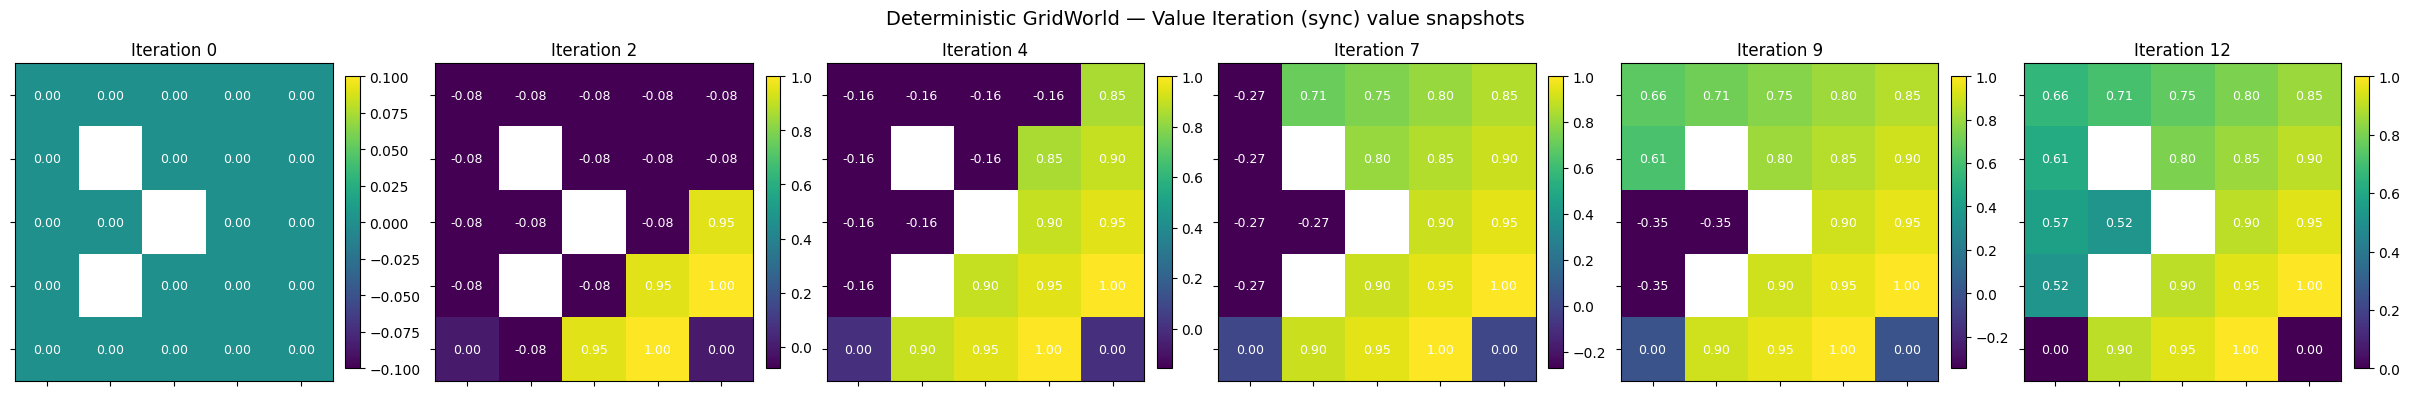

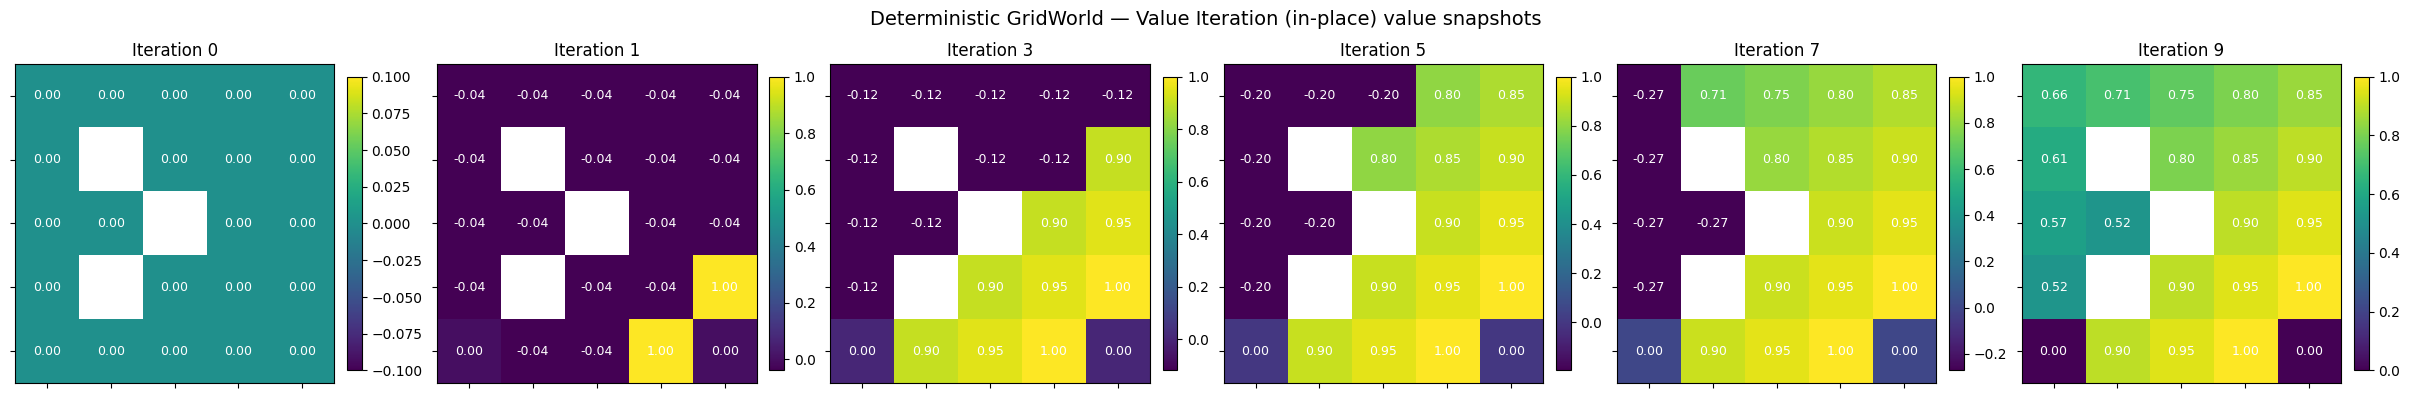

In [21]:

plot_value_snapshots(
    vi_det_sync["history"],
    det_env,
    title="Deterministic GridWorld — Value Iteration (sync) value snapshots",
    max_panels=6,
)

plot_value_snapshots(
    vi_det_inpl["history"],
    det_env,
    title="Deterministic GridWorld — Value Iteration (in-place) value snapshots",
    max_panels=6,
)

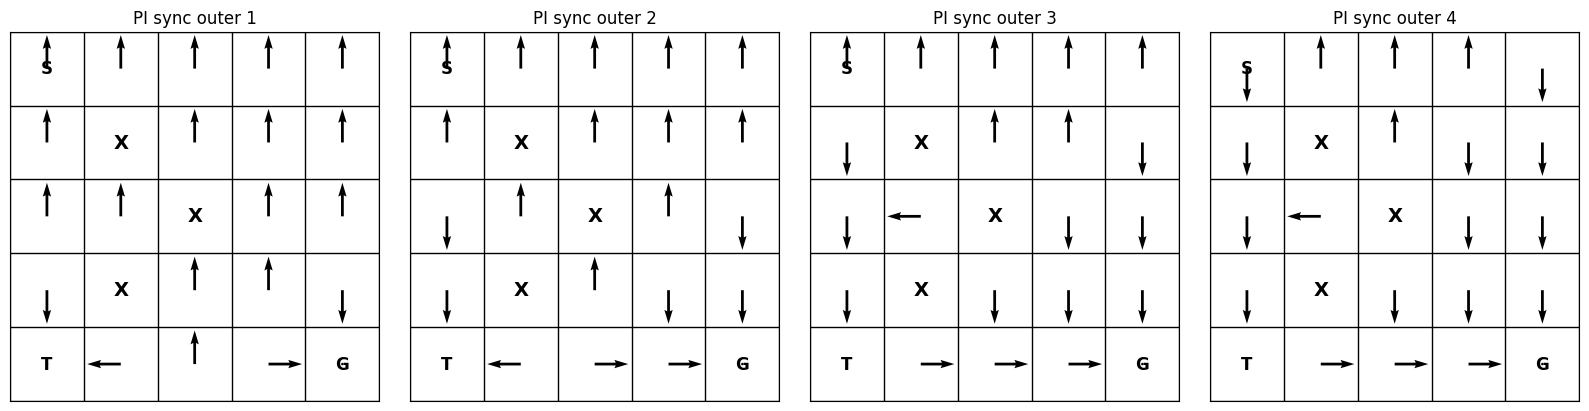

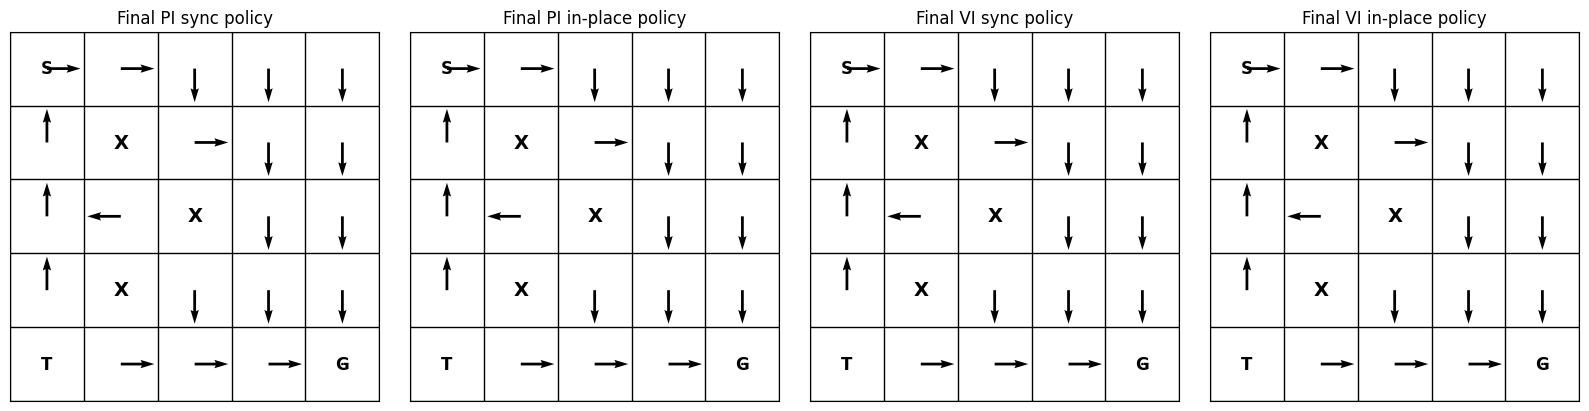

In [22]:

det_policy_list = [step["policy"] for step in pi_det_sync["history"][:4]]
det_policy_titles = [f"PI sync outer {i+1}" for i in range(len(det_policy_list))]
plot_policy_snapshots(det_policy_list, det_env, det_policy_titles)

plot_policy_snapshots(
    [pi_det_sync["policy"], pi_det_inpl["policy"], vi_det_sync["policy"], vi_det_inpl["policy"]],
    det_env,
    [
        "Final PI sync policy",
        "Final PI in-place policy",
        "Final VI sync policy",
        "Final VI in-place policy",
    ],
)

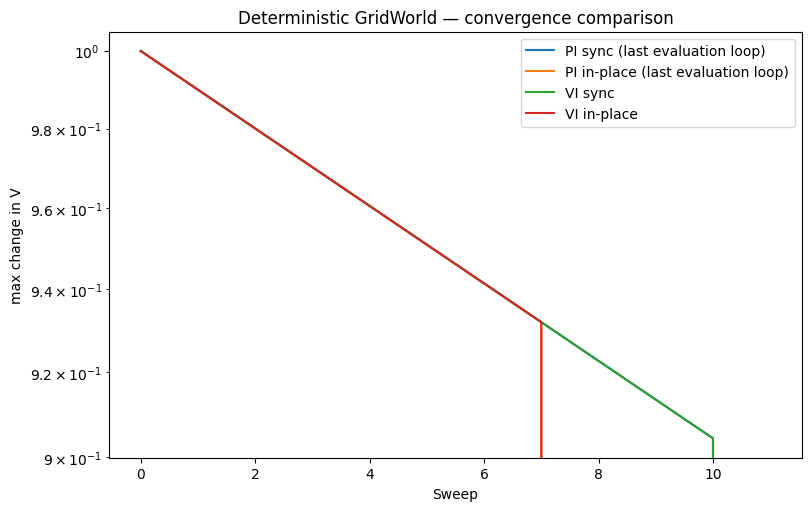

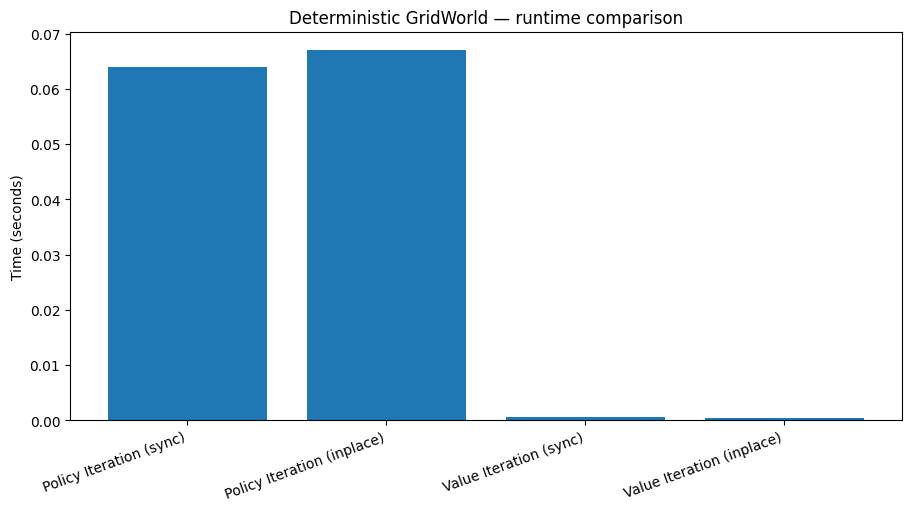

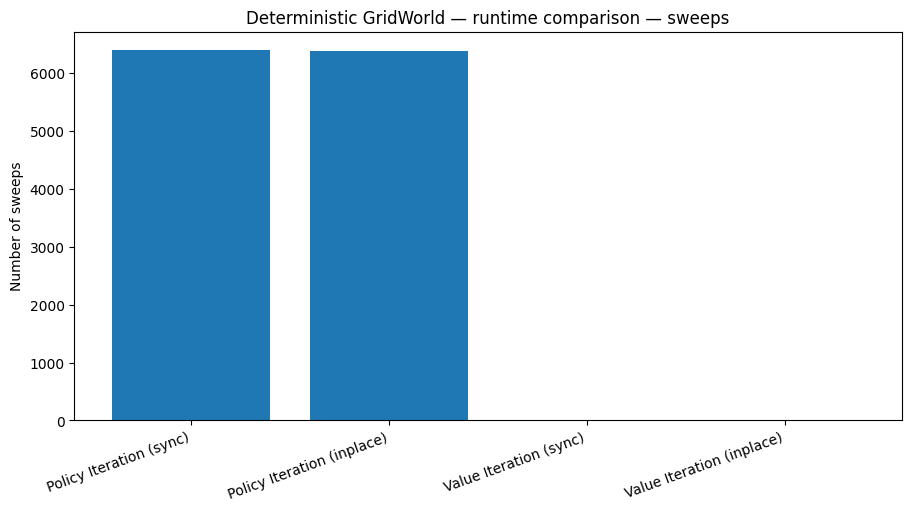

In [23]:

plot_convergence(
    {
        "PI sync (last evaluation loop)": pi_det_sync["history"][-1]["eval_deltas"],
        "PI in-place (last evaluation loop)": pi_det_inpl["history"][-1]["eval_deltas"],
        "VI sync": vi_det_sync["deltas"],
        "VI in-place": vi_det_inpl["deltas"],
    },
    title="Deterministic GridWorld — convergence comparison",
)

compare_runtime_bar(det_summary, "Deterministic GridWorld — runtime comparison")

## 7. Run the Same Four Algorithms on the Stochastic GridWorld

In [24]:

pi_sto_sync = policy_iteration(P_sto, gamma=gamma, theta=theta, mode="sync")
pi_sto_inpl = policy_iteration(P_sto, gamma=gamma, theta=theta, mode="inplace")
vi_sto_sync = value_iteration(P_sto, gamma=gamma, theta=theta, mode="sync")
vi_sto_inpl = value_iteration(P_sto, gamma=gamma, theta=theta, mode="inplace")

sto_summary = [
    {"Algorithm": pi_sto_sync["algorithm"], "Sweeps": pi_sto_sync["total_sweeps"], "Time (s)": pi_sto_sync["time_seconds"]},
    {"Algorithm": pi_sto_inpl["algorithm"], "Sweeps": pi_sto_inpl["total_sweeps"], "Time (s)": pi_sto_inpl["time_seconds"]},
    {"Algorithm": vi_sto_sync["algorithm"], "Sweeps": vi_sto_sync["sweeps"], "Time (s)": vi_sto_sync["time_seconds"]},
    {"Algorithm": vi_sto_inpl["algorithm"], "Sweeps": vi_sto_inpl["sweeps"], "Time (s)": vi_sto_inpl["time_seconds"]},
]

for row in sto_summary:
    print(row)

{'Algorithm': 'Policy Iteration (sync)', 'Sweeps': 3437, 'Time (s)': 0.07314579200465232}
{'Algorithm': 'Policy Iteration (inplace)', 'Sweeps': 3989, 'Time (s)': 0.07315279205795377}
{'Algorithm': 'Value Iteration (sync)', 'Sweeps': 36, 'Time (s)': 0.003017666982486844}
{'Algorithm': 'Value Iteration (inplace)', 'Sweeps': 25, 'Time (s)': 0.0021001669811084867}


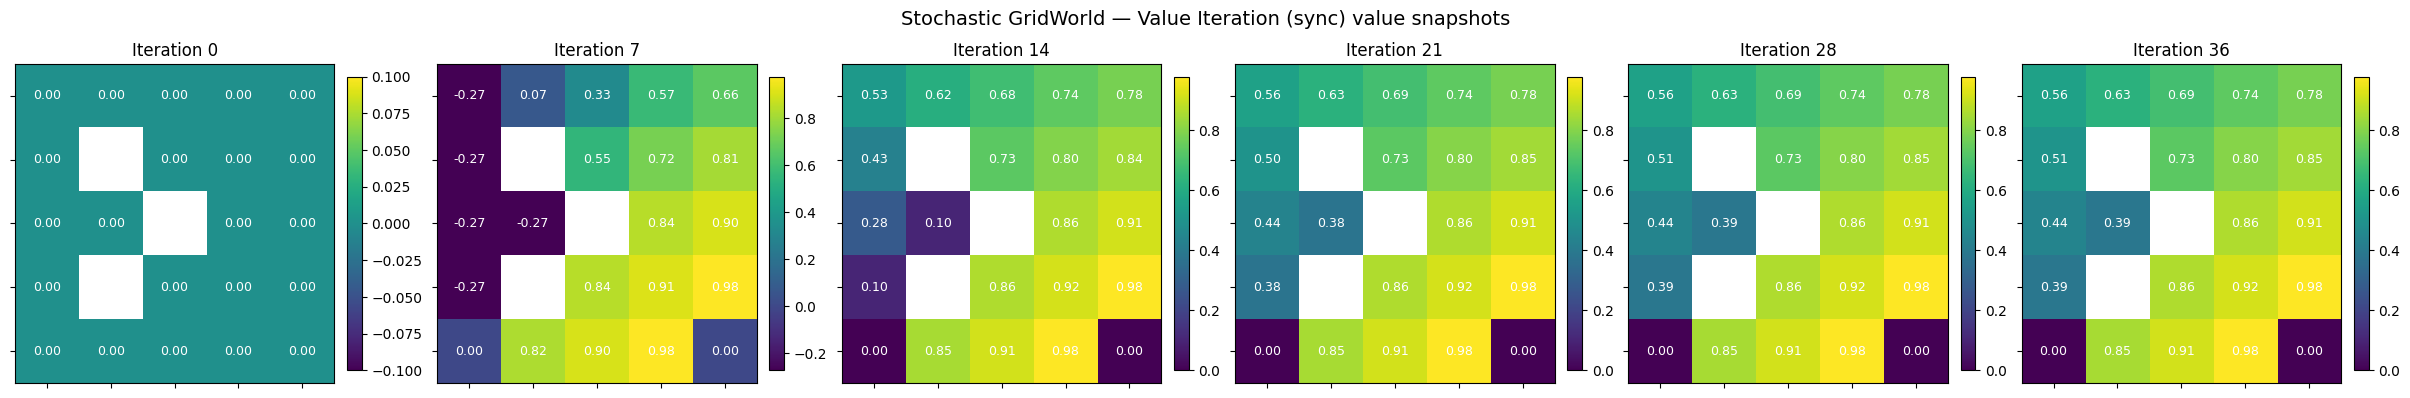

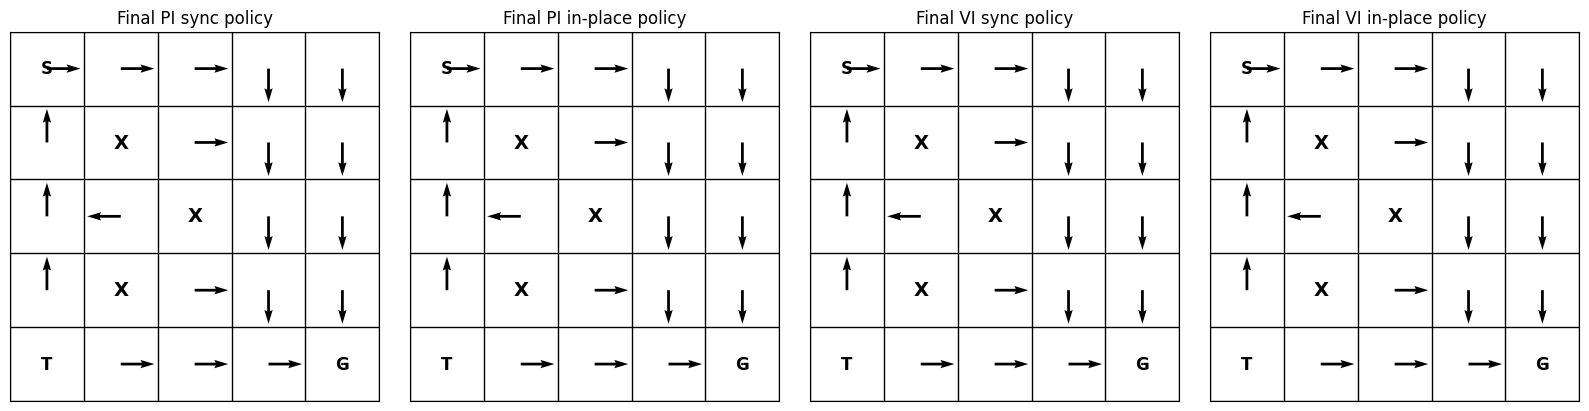

In [25]:

plot_value_snapshots(
    vi_sto_sync["history"],
    stoch_env,
    title="Stochastic GridWorld — Value Iteration (sync) value snapshots",
    max_panels=6,
)

plot_policy_snapshots(
    [pi_sto_sync["policy"], pi_sto_inpl["policy"], vi_sto_sync["policy"], vi_sto_inpl["policy"]],
    stoch_env,
    [
        "Final PI sync policy",
        "Final PI in-place policy",
        "Final VI sync policy",
        "Final VI in-place policy",
    ],
)

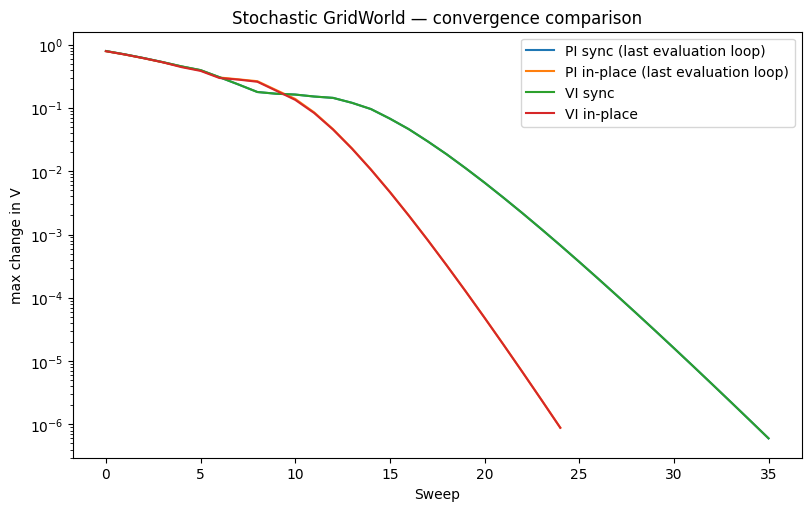

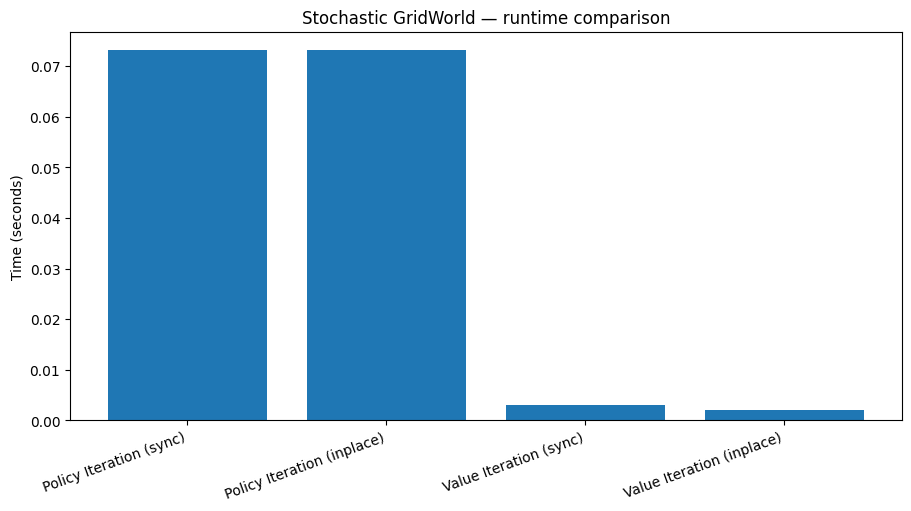

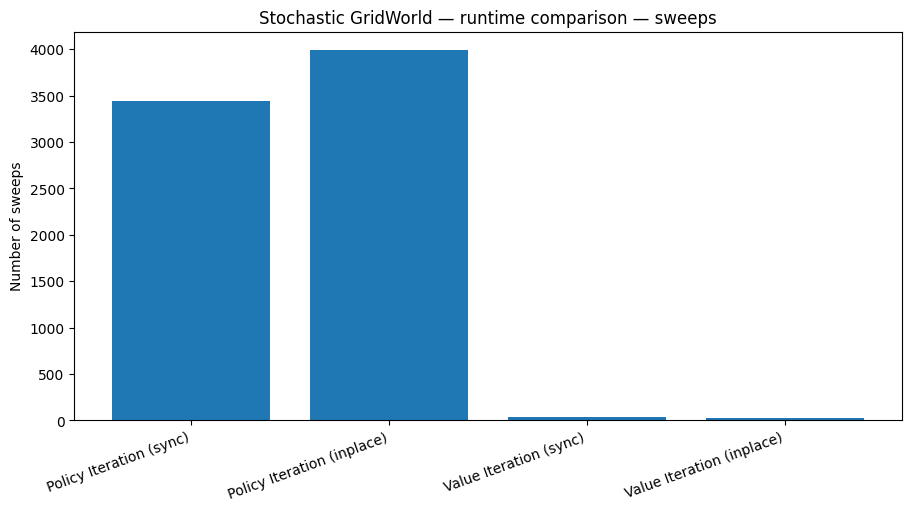

In [26]:

plot_convergence(
    {
        "PI sync (last evaluation loop)": pi_sto_sync["history"][-1]["eval_deltas"],
        "PI in-place (last evaluation loop)": pi_sto_inpl["history"][-1]["eval_deltas"],
        "VI sync": vi_sto_sync["deltas"],
        "VI in-place": vi_sto_inpl["deltas"],
    },
    title="Stochastic GridWorld — convergence comparison",
)

compare_runtime_bar(sto_summary, "Stochastic GridWorld — runtime comparison")

## 8. FrozenLake-v1 with Gymnasium's Transition Dynamics

FrozenLake already stores the full model in `env.unwrapped.P[s][a]`.
Each entry is a list of tuples of the form:

```python
(probability, next_state, reward, terminated)
```

In [27]:

if gym is None:
    print("Install gymnasium first to run FrozenLake.")
else:
    env_fl_det = gym.make("FrozenLake-v1", is_slippery=False)
    env_fl_sto = gym.make("FrozenLake-v1", is_slippery=True)

    P_fl_det, nS_fl_det, nA_fl_det = extract_transition_model(env_fl_det)
    P_fl_sto, nS_fl_sto, nA_fl_sto = extract_transition_model(env_fl_sto)

    print("FrozenLake deterministic example:")
    print(P_fl_det[0][2])

    print("\nFrozenLake slippery example:")
    print(P_fl_sto[0][2])

FrozenLake deterministic example:
[(1.0, 1, 0, False)]

FrozenLake slippery example:
[(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]


In [28]:

if gym is not None:
    fl_pi_sync = policy_iteration(P_fl_sto, gamma=0.99, theta=1e-8, mode="sync")
    fl_pi_inpl = policy_iteration(P_fl_sto, gamma=0.99, theta=1e-8, mode="inplace")
    fl_vi_sync = value_iteration(P_fl_sto, gamma=0.99, theta=1e-8, mode="sync")
    fl_vi_inpl = value_iteration(P_fl_sto, gamma=0.99, theta=1e-8, mode="inplace")

    frozen_summary = [
        {"Algorithm": fl_pi_sync["algorithm"], "Sweeps": fl_pi_sync["total_sweeps"], "Time (s)": fl_pi_sync["time_seconds"]},
        {"Algorithm": fl_pi_inpl["algorithm"], "Sweeps": fl_pi_inpl["total_sweeps"], "Time (s)": fl_pi_inpl["time_seconds"]},
        {"Algorithm": fl_vi_sync["algorithm"], "Sweeps": fl_vi_sync["sweeps"], "Time (s)": fl_vi_sync["time_seconds"]},
        {"Algorithm": fl_vi_inpl["algorithm"], "Sweeps": fl_vi_inpl["sweeps"], "Time (s)": fl_vi_inpl["time_seconds"]},
    ]

    for row in frozen_summary:
        print(row)

{'Algorithm': 'Policy Iteration (sync)', 'Sweeps': 1426, 'Time (s)': 0.015140166971832514}
{'Algorithm': 'Policy Iteration (inplace)', 'Sweeps': 1147, 'Time (s)': 0.012886125012300909}
{'Algorithm': 'Value Iteration (sync)', 'Sweeps': 438, 'Time (s)': 0.024640874937176704}
{'Algorithm': 'Value Iteration (inplace)', 'Sweeps': 324, 'Time (s)': 0.017066207947209477}


## 9. Compact Helper to Visualize FrozenLake Policies

In [29]:

def print_policy_grid(policy, shape=(4, 4), hole_states=None, goal_state=None):
    hole_states = set(hole_states or [])
    rows, cols = shape
    for r in range(rows):
        line = []
        for c in range(cols):
            s = r * cols + c
            if s in hole_states:
                line.append("H")
            elif goal_state is not None and s == goal_state:
                line.append("G")
            else:
                line.append(ACTION_ARROWS[policy[s]])
        print(" ".join(line))

if gym is not None:
    hole_states = {5, 7, 11, 12}
    goal_state = 15
    print("FrozenLake slippery — final policy from Value Iteration (in-place):")
    print_policy_grid(fl_vi_inpl["policy"], shape=(4, 4), hole_states=hole_states, goal_state=goal_state)

FrozenLake slippery — final policy from Value Iteration (in-place):
↑ → → →
↑ H ↑ H
→ ↓ ↑ H
H ← ↓ G


## 10. Unified Comparison Table

In [30]:

def show_summary_table(title, rows):
    print(title)
    print("-" * len(title))
    for row in rows:
        print(f"{row['Algorithm']:<28} | sweeps = {row['Sweeps']:<8} | time = {row['Time (s)']:.6f} s")

show_summary_table("Deterministic GridWorld", det_summary)
print()
show_summary_table("Stochastic GridWorld", sto_summary)
print()
if gym is not None:
    show_summary_table("FrozenLake (slippery)", frozen_summary)

Deterministic GridWorld
-----------------------
Policy Iteration (sync)      | sweeps = 6394     | time = 0.063980 s
Policy Iteration (inplace)   | sweeps = 6387     | time = 0.067036 s
Value Iteration (sync)       | sweeps = 12       | time = 0.000693 s
Value Iteration (inplace)    | sweeps = 9        | time = 0.000484 s

Stochastic GridWorld
--------------------
Policy Iteration (sync)      | sweeps = 3437     | time = 0.073146 s
Policy Iteration (inplace)   | sweeps = 3989     | time = 0.073153 s
Value Iteration (sync)       | sweeps = 36       | time = 0.003018 s
Value Iteration (inplace)    | sweeps = 25       | time = 0.002100 s

FrozenLake (slippery)
---------------------
Policy Iteration (sync)      | sweeps = 1426     | time = 0.015140 s
Policy Iteration (inplace)   | sweeps = 1147     | time = 0.012886 s
Value Iteration (sync)       | sweeps = 438      | time = 0.024641 s
Value Iteration (inplace)    | sweeps = 324      | time = 0.017066 s
